# Time-averaging on a moving vertical grid

HYCOM's vertical coordinate is *Lagrangian*, the hybrid layers move with the flow and, in the interior, are isopycnals. So a monthly mean can be built in more than one way, and the choices differ:

1. **Isopycnal**: thickness-weighted average on the native layers, then regrid. A natural default: it is the mean HYCOM itself forms online, conservative, and cheap.
2. **Eulerian**: regrid to depth each day, then average at fixed depth. The right match for a z-level product like GLORYS.

A common mistake is to average the layer values *without* thickness-weighting. This is not a valid third method, it does not conserve layer content, and the thickness weight is what makes a layer mean physically meaningful. The notebook shows what it produces so the error is recognisable.

This notebook is about the method, not the `xhycom` API (see **[Regridding](regridding.ipynb)**).

In [1]:
import numpy as np
import xarray as xr
import xhycom
import matplotlib.pyplot as plt

## Setup

Reusing the TP2 archive year, grid, and GLORYS target from the [Regridding](regridding.ipynb) notebook.

In [2]:
import os

grid = "/cluster/home/nlo043/NERSC-HYCOM-CICE/TP2a0.10/topo/regional.grid"
DATA_PATH = "/nird/datalake/NS9481K/shuang/TP2_output/expt_02.8/"
GRIDS = "/nird/datapeak/NS9481K/MERCATOR_DATA/REGULAR_GRID_COORD"

os.environ["XHYCOM_CACHE_DIR"] = f"/cluster/projects/nn2993k/{os.environ['USER']}/.xhycom-cache-dir"

ds = xhycom.open_mfdataset(DATA_PATH + "archm.2020*", grid=grid, chunks={"time": 1}, postprocess=True)
glorys = xr.open_dataset(f"{GRIDS}/GLO-MFC_001_030_mask_bathy.nc")

## Two ways to build a monthly mean

Write the field (say salinity) as $S_{k,t}$ on layer $k$ at time $t=1\dots N$, with layer thickness $h_{k,t}$ (`thknss`), and let $\mathcal{R}_z[\,S_k,h_k\,]$ be the remap of a column from layers onto depth $z$.

**1. Isopycnal: thickness-weighted on layers, then remap**

$$\bar S_k=\frac{\sum_t h_{k,t}\,S_{k,t}}{\sum_t h_{k,t}},\qquad \bar h_k=\frac1N\sum_t h_{k,t},\qquad S^{\mathrm{iso}}(z)=\mathcal{R}_z\!\left[\,\bar S_k,\ \bar h_k\,\right].$$

**2. Eulerian: remap each time, then average at fixed depth**

$$S^{\mathrm{eul}}(z)=\frac1N\sum_t \mathcal{R}_z\!\left[\,S_{k,t},\ h_{k,t}\,\right].$$

The vertical remap depends on the time-varying $h_{k,t}$, so it does **not** commute with the time mean, that is why (1) and (2) differ. (The horizontal remap is a fixed linear map and commutes, so it can go before or after the time mean.)

| method | weight per time | result | when |
|---|---|---|---|
| isopycnal | $h_{k,t}$ | the HYCOM monthly mean | a good default |
| Eulerian | $h_{k,t}$ (in the remap) | fixed-depth mean | match GLORYS |

### The unweighted layer mean: a common mistake

Replacing $h_{k,t}$ with $1$ in method (1) gives

$$\tilde S_k=\frac1N\sum_t S_{k,t},\qquad S^{\mathrm{bad}}(z)=\mathcal{R}_z\!\left[\,\tilde S_k,\ \bar h_k\,\right].$$

This is wrong: it weights each time step by the *number* of layers it contributes rather than by how much water they hold, so it does not conserve layer content. Because thicknesses vary significantly in time (layers thin and thicken as isopycnals heave), the error is not small. Since thickness-weighting costs nothing, there is no reason to use this form.

## Compare on one month

Build the January mean three ways and difference each against the isopycnal one, on a meridional salinity section at 0° with a shared colour scale. The third panel shows what the unweighted mistake looks like in practice.

In [3]:
ds_m = ds.isel(time=slice(0, 31))                 # January
zlev = glorys["depth"].values
h = ds_m["thknss"]; hbar = h.mean("time")

# (1) isopycnal: thickness-weighted on layers, then regrid
iso_native = (ds_m[["temp", "salin"]] * h).mean("time") / hbar.where(hbar > 0)
iso_native["thknss"] = hbar
iso = xhycom.regrid(iso_native, target=glorys, grid=grid, weights=True)

# (2) Eulerian: regrid to depth daily, average at fixed depth, then one horizontal remap
ds_mz = xhycom.regrid_vertical(ds_m[["temp", "salin", "thknss"]], depth=zlev)
eul = xhycom.regrid_horizontal(ds_mz[["temp", "salin"]].mean("time"),
                               target=glorys, grid=grid, weights=True)

# (3) unweighted layer mean
bad_native = ds_m[["temp", "salin"]].mean("time")
bad_native["thknss"] = hbar
bad = xhycom.regrid(bad_native, target=glorys, grid=grid, weights=True)

In [4]:
sec_iso = iso["salin"].sel(lon=0, method="nearest").compute()
d_eul = (eul["salin"].sel(lon=0, method="nearest") - sec_iso).compute()
d_bad = (bad["salin"].sel(lon=0, method="nearest") - sec_iso).compute()

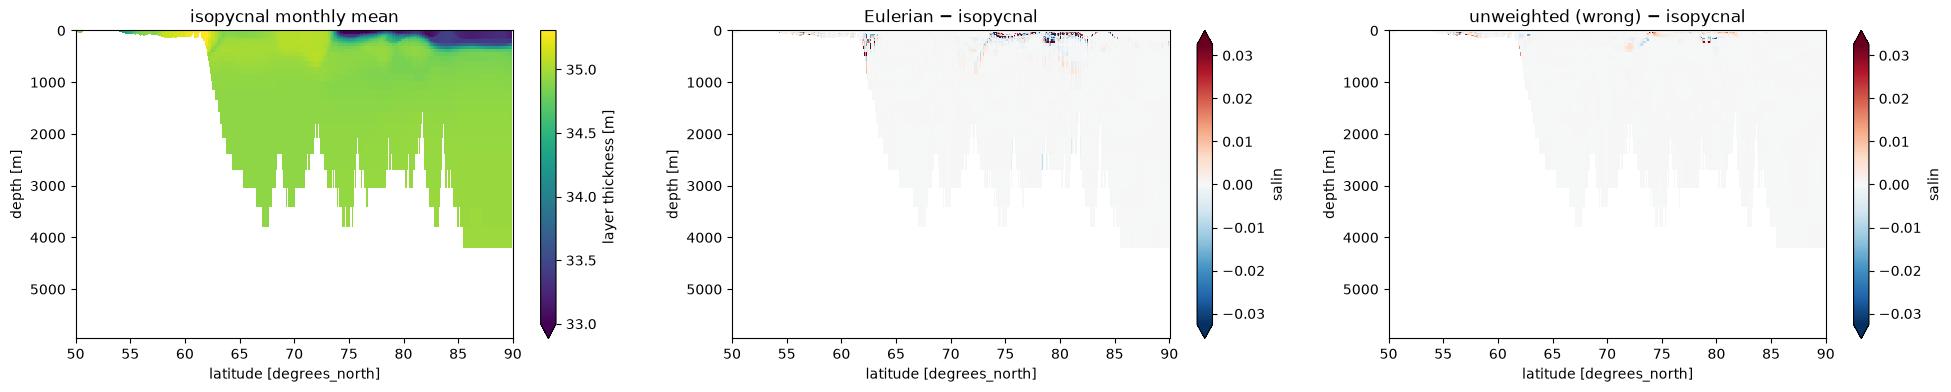

In [6]:
kw = dict(x="lat", y="depth", yincrease=False)

lim = float(abs(d_eul).quantile(0.99))            # shared colour scale

fig, axs = plt.subplots(1, 3, figsize=(24, 4))
sec_iso.plot(ax=axs[0], vmin=33, cmap="viridis", **kw)
d_eul.plot(ax=axs[1], cmap="RdBu_r", vmin=-lim, vmax=lim, **kw)
d_bad.plot(ax=axs[2], cmap="RdBu_r", vmin=-lim, vmax=lim, **kw)
axs[0].set_title("isopycnal monthly mean")
axs[1].set_title("Eulerian − isopycnal")
axs[2].set_title("unweighted (wrong) − isopycnal")
for ax in axs:
    ax.set_xlim(50, None)

## Why thickness-weighting

It is the mean HYCOM forms online for `archm` files (`mod_mean.F`: accumulate $S\,dp$ and $dp$, divide at the end, fill massless layers from the layer above). Being associative, a thickness-weighted mean across daily `archm` files reproduces the monthly `archm` exactly. It also conserves each layer's content, which the unweighted mean does not, that is the reason to prefer it. (`thknss` is the layer thickness up to the tiny free-surface factor $\texttt{oneta}=1+\mathrm{SSH}/\mathrm{depth}$, which cancels in a weighted mean.)

## Summary

- Default to the **thickness-weighted (isopycnal)** monthly mean, the mean HYCOM computes online, conservative, and cheap.
- Use the **Eulerian** (fixed-depth) mean for a strict like-for-like against GLORYS's z-level monthly means.
- **Do not use the unweighted layer mean.** It does not conserve layer content and has no advantage over the isopycnal mean.